In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import VGG16, InceptionV3, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_input_vgg
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_input_inception
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_input_resnet
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the reshaped datasets
X_train_resized = np.load('/content/drive/MyDrive/SETS/X_train_resized.npy')
X_test_resized = np.load('/content/drive/MyDrive/SETS/X_test_resized.npy')
y_train = np.load('/content/drive/MyDrive/SETS/y_train_resized.npy')
y_test = np.load('/content/drive/MyDrive/SETS/y_test_resized.npy')

In [ ]:
# Preprocess the data for each model
X_test_resized_vgg = preprocess_input_vgg(np.repeat(X_test_resized, 3, axis=-1))
X_test_resized_inception = preprocess_input_inception(np.repeat(X_test_resized, 3, axis=-1))
X_test_resized_resnet = preprocess_input_resnet(np.repeat(X_test_resized, 3, axis=-1))

In [ ]:
# Load the trained models
model_vgg16 = load_model('/content/drive/MyDrive/MODElS/vgg2.h5')
model_inception = load_model('/content/drive/MyDrive/MODElS/inception.h5')
model_resnet = load_model('/content/drive/MyDrive/MODElS/resNet.h5')

In [ ]:
# Define a function to get model predictions
def get_model_predictions(model, X):
    return model.predict(X)

# Prepare meta features for stacking
X_test_meta = np.concatenate([
    get_model_predictions(model_vgg16, X_test_resized_vgg),
    get_model_predictions(model_inception, X_test_resized_inception),
    get_model_predictions(model_resnet, X_test_resized_resnet)
], axis=1)

# Create the stacking classifier
estimators = [
    ('vgg16', make_pipeline(StandardScaler(), LogisticRegression())),
    ('inception', make_pipeline(StandardScaler(), LogisticRegression())),
    ('resnet', make_pipeline(StandardScaler(), LogisticRegression()))
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

# Fit the stacking classifier on the meta features
stacking_clf.fit(X_test_meta, y_test)

406/406 [==============================] - 7s 13ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

StackingClassifier(estimators=[('vgg16',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression())])),
                               ('inception',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression())])),
                               ('resnet',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression())]))],
                   final_estimator=LogisticRegression())

In [ ]:
# Make predictions with the stacking classifier on the test set
y_pred_ensemble = stacking_clf.predict(X_test_meta)

# Evaluate the ensemble model on the test set
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
conf_matrix_ensemble = confusion_matrix(y_test, y_pred_ensemble)
class_report_ensemble = classification_report(y_test, y_pred_ensemble)
roc_auc_ensemble = roc_auc_score(y_test, stacking_clf.predict_proba(X_test_meta), multi_class='ovr')

print(f"Ensemble Model Accuracy: {accuracy_ensemble}")
print("Ensemble Model Classification Report:")
print(class_report_ensemble)
print(f"Ensemble Model ROC AUC Score: {roc_auc_ensemble}")

Ensemble Model Accuracy: 0.9621987835861113
Ensemble Model Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     10075
           1       0.98      0.96      0.97       971
           2       0.97      0.95      0.96       976
           3       0.94      0.77      0.85       250
           4       0.85      0.70      0.77       717

    accuracy                           0.96     12989
   macro avg       0.94      0.87      0.90     12989
weighted avg       0.96      0.96      0.96     12989

Ensemble Model ROC AUC Score: 0.9839683240320255


In [ ]:
# Calculate the true and false predictions
true_correct_ensemble = np.sum(y_test == y_pred_ensemble)
false_predictions_ensemble = np.sum(y_test != y_pred_ensemble)

print(f"Ensemble Model True Correct Predictions: {true_correct_ensemble}")
print(f"Ensemble Model False Predictions: {false_predictions_ensemble}")

Ensemble Model True Correct Predictions: 12498
Ensemble Model False Predictions: 491


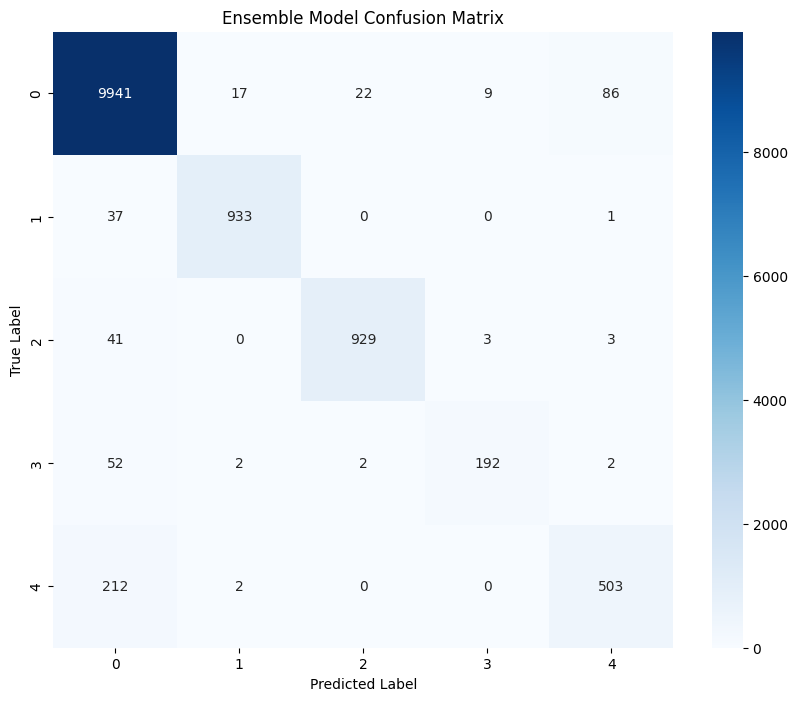

In [ ]:
# Plot confusion matrix for ensemble model
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_ensemble, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Ensemble Model Confusion Matrix')
plt.show()

In [ ]:
# Save the ensemble model test set predictions
ensemble_test_set = {
    'X_test_meta': X_test_meta,
    'y_test': y_test,
    'y_pred_ensemble': y_pred_ensemble
}

# Save to a .npz file
np.savez('/content/drive/MyDrive/SETS/ensemble_test_set.npz', **ensemble_test_set)

In [ ]:
# Function to evaluate individual models 
def evaluate_model(model, X, y, preprocess_input, model_name):
    X_preprocessed = preprocess_input(np.repeat(X, 3, axis=-1))
    y_pred_probs = model.predict(X_preprocessed)
    y_pred = np.argmax(y_pred_probs, axis=1)
    accuracy = accuracy_score(y, y_pred)
    return accuracy, model_name

# Evaluate individual models
accuracy_vgg16, model_name_vgg16 = evaluate_model(model_vgg16, X_test_resized, y_test, preprocess_input_vgg, "VGG16")
accuracy_inception, model_name_inception = evaluate_model(model_inception, X_test_resized, y_test, preprocess_input_inception, "InceptionV3")
accuracy_resnet, model_name_resnet = evaluate_model(model_resnet, X_test_resized, y_test, preprocess_input_resnet, "ResNet50")

accuracies = [accuracy_vgg16, accuracy_inception, accuracy_resnet, accuracy_ensemble]
model_names = [model_name_vgg16, model_name_inception, model_name_resnet, "Ensemble"]




406/406 [==============================] - 5s 12ms/step


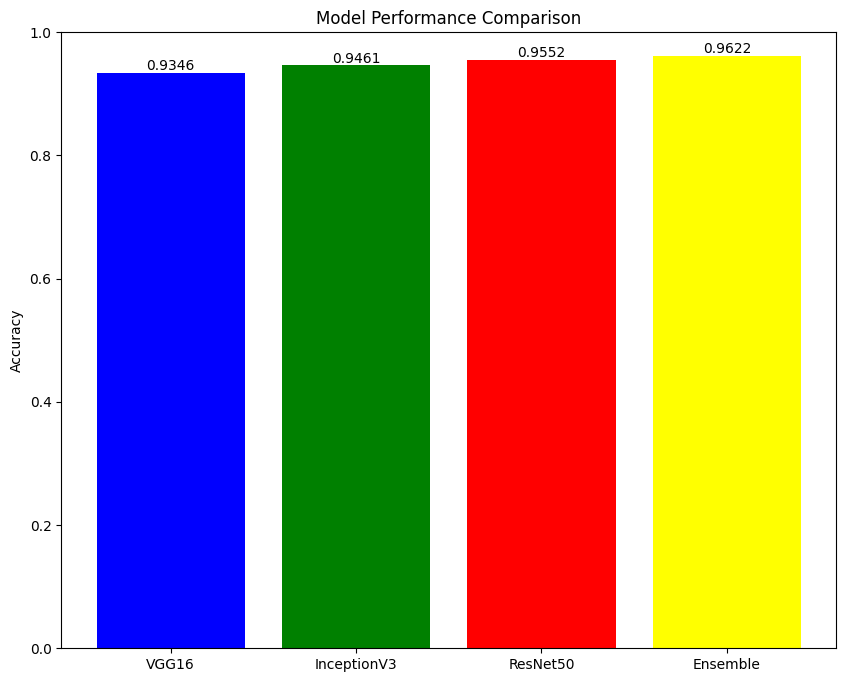

In [ ]:
# Define colors for each model
colors = ['blue', 'green', 'red', 'yellow']

plt.figure(figsize=(10, 8))
plt.bar(model_names, accuracies, color=colors)
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
for index, value in enumerate(accuracies):
    plt.text(index, value, f'{value:.4f}', ha='center', va='bottom')
plt.show()

In [ ]:
# Save the stacking classifier
joblib.dump(stacking_clf, '/content/drive/MyDrive/SETS/MIT_stacking_clf.pkl')

# Save the test set for the ensemble model
np.save('/content/drive/MyDrive/SETS/X_test_meta.npy', X_test_meta)
np.save('/content/drive/MyDrive/SETS/y_test.npy', y_test)

In [ ]:
# Save the trained models
model_vgg16.save('/content/drive/MyDrive/SETS/vgg16_model.h5')
model_inception.save('/content/drive/MyDrive/SETS/inception_model.h5')
model_resnet.save('/content/drive/MyDrive/SETS/resnet_model.h5')


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
